# Numerical Simulation Laboratory - Exercise 08

## INTRODUCTION

### Physical problem and variational principle

In this exercise we study a single quantum particle in one dimension, confined by the double-well potential

$$
V(x)=x^4-\frac{5}{2}x^2 .
$$

The corresponding time-independent Schrödinger equation can not be solved analytically. The goal is therefore to approximate the ground state by numerical methods.

The key theoretical tool is the variational principle. For any normalized trial wave function $\Psi_T$, the expectation value of the Hamiltonian satisfies

$$
\langle \hat H \rangle_T =
\frac{\int dx\, \Psi_T^*(x)\hat H\Psi_T(x)}
{\int dx\, |\Psi_T(x)|^2}
\geq E_0,
$$

where $E_0$ is the exact ground-state energy. This means that the variational estimate is an upper bound for the true ground-state energy. The aim is therefore to optimize the parameters of the trial wave function in order to make $\langle \hat H\rangle_T$ as close as possible to $E_0$ from above. Within the chosen family of trial functions, this corresponds to searching for the best approximation to the true ground state.

### Trial wave function

The trial wave function used in the exercise is

$$
\Psi_T^{\sigma,\mu}(x) \propto
\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right]
+
\exp\left[-\frac{(x+\mu)^2}{2\sigma^2}\right] .
$$

It is the sum of two Gaussian functions centered around $+\mu$ and $-\mu$. This is a natural choice for a symmetric double-well potential: the ground state is expected to be even, with probability density concentrated around the two wells. The parameter $\mu$ controls the separation of the two peaks, while $\sigma$ controls their width.

### Variational Monte Carlo

Starting from the expectation value of the Hamiltonian, which gives the average energy of the trial state,

$$
\langle \hat H \rangle_T =
\frac{\int dx\, \Psi_T^*(x)\hat H\Psi_T(x)}
{\int dx\, |\Psi_T(x)|^2},
$$

and using the fact that the trial wave function is real, the integrand can be rewritten as

$$
\Psi_T(x)\hat H\Psi_T(x)
=
|\Psi_T(x)|^2
\frac{\hat H\Psi_T(x)}{\Psi_T(x)} .
$$

Therefore,

$$
\langle \hat H \rangle_T =
\int dx\,
\frac{|\Psi_T(x)|^2}{\int dx\, |\Psi_T(x)|^2}
\frac{\hat H\Psi_T(x)}{\Psi_T(x)} .
$$

This expression has the form of an average over the probability density

$$
p_T(x)=\frac{|\Psi_T(x)|^2}{\int dx\, |\Psi_T(x)|^2}.
$$

The quantity averaged over this distribution is the local energy,

$$
E_L(x)=\frac{\hat H\Psi_T(x)}{\Psi_T(x)},
$$

as it is a function of the sampled position $x$. For each point visited by the Metropolis algorithm, the Hamiltonian is applied to the trial wave function and the result is divided by the value of the trial wave function at the same point.

For the Hamiltonian used in this exercise,

$$
\hat H = -\frac{1}{2}\frac{d^2}{dx^2}+V(x),
$$

the local energy can be written as

$$
E_L(x)=
-\frac{1}{2}\frac{\Psi_T''(x)}{\Psi_T(x)}
+V(x).
$$

Therefore, during the Monte Carlo simulation, each sampled position $x_i$ gives one value $E_L(x_i)$, and the variational energy is obtained by averaging these values over the sampled distribution:

$$
\langle \hat H\rangle_T
=
\left\langle E_L(x)\right\rangle_{p_T}.
$$

If $\Psi_T$ were the exact ground-state wave function, the local energy would be constant and equal to the exact ground-state energy. Since $\Psi_T$ is only a trial wave function, $E_L(x)$ fluctuates with $x$, and its average gives the variational estimate of the energy.

This is the central idea of Variational Monte Carlo. Instead of computing the integral directly, the Metropolis algorithm is used to generate positions distributed according to $p_T(x)\propto |\Psi_T(x)|^2$. For each sampled position, the local energy $E_L(x)$ is evaluated, and the variational energy is estimated as the average of these values.

In order to sample the probability distribution

$$
p_T(x)\propto |\Psi_T(x)|^2,
$$

the Metropolis algorithm starts from the current position $x$ and proposes a new position by adding a random displacement:

$$
x'=x+\delta .
$$

In the present implementation, the displacement is extracted uniformly in the interval

$$
\delta \in [-1.2,1.2].
$$

This symmetry is important because the probability of proposing the move $x\to x'$ is the same as the probability of proposing the reverse move $x'\to x$. Therefore, in the Metropolis acceptance rule, the proposal probabilities cancel out. The acceptance probability only depends on how probable the new point is with respect to the old one according to the target distribution $p_T(x)$:

$$
A(x\to x')=
\min\left(1,\frac{p_T(x')}{p_T(x)}\right).
$$

Since the normalization constant of $p_T(x)$ is the same for $x$ and $x'$, it also cancels in the ratio. Therefore,

$$
\frac{p_T(x')}{p_T(x)}
=
\frac{|\Psi_T(x')|^2}{|\Psi_T(x)|^2},
$$

and the acceptance probability becomes

$$
A(x\to x')=
\min\left(1,
\frac{|\Psi_T(x')|^2}{|\Psi_T(x)|^2}
\right).
$$

If the new point has a larger value of $|\Psi_T|^2$, it is always accepted. If it has a smaller value, it can still be accepted with a probability equal to the ratio above.


### Simulated Annealing

Once $\mu$ and $\sigma$ are fixed, the Variational Monte Carlo code provides an estimate of the variational energy

$$
E(\mu,\sigma)=\langle \hat H\rangle_T .
$$

The problem is therefore an optimization problem: among all the trial wave functions belonging to the chosen family, we want to find the values of $\mu$ and $\sigma$ that minimize $E(\mu,\sigma)$. According to the variational principle, this gives the best approximation to the ground state within the chosen trial family.

In Exercise 08.2 this minimization is performed with Simulated Annealing. Simulated Annealing is a stochastic optimization algorithm: instead of following a deterministic direction, it explores the parameter space through random trial moves and accepts or rejects them according to a temperature-dependent Metropolis rule.

The algorithm proposes random moves in the variational parameter space, for example

$$
\mu' = \mu + \delta\mu, \qquad \sigma'=\sigma+\delta\sigma,
$$

and accepts or rejects the new parameters with a Metropolis rule based on the variational energy:

$$
A = \min\left(1,\exp\left[-\frac{E_{new}-E_{old}}{T}\right]\right).
$$

At high temperature, Simulated Annealing can also accept moves that increase the energy. This is useful because the algorithm is not forced to go immediately toward the nearest minimum, and it can still escape from local minima.

When the temperature is gradually lowered, moves that increase the energy become less likely. The search then becomes more stable and concentrates around the best region found. In this way, the algorithm first explores the parameter space and then slowly converges toward the minimum.

The gradual cooling is therefore the central idea of Simulated Annealing: large exploration at the beginning, followed by progressive stabilization near the optimum.

In the C++ implementation used here, the temperature is decreased according to

$$
T_i = \frac{1}{i+1},
$$

where $i$ is the temperature index. The proposal steps for $\mu$ and $\sigma$ are uniform and fixed in size during the run. This point is important because the cooling is applied only through the acceptance probability, not by explicitly reducing the proposal width.

A useful analogy is with stochastic optimization methods where the amount of exploration is reduced during the run. For example, in stochastic gradient descent one often decreases the learning rate to make the search more stable near the minimum.

### Numerical reference solution

For the comparison with the exact numerical solution, the supplementary material suggested in the exercise is used.

How can we describe a wave function as a vector? We set up a lattice of discrete points, spaced by a constant distance $dx$, and record the value of the function at each lattice point. In this way the wave function, $\Psi(x)$ become a vector:

$$
\Psi(x) \to \left[ \Psi(x_1), \Psi(x_2), ..., \Psi(x_N) \right] = 
\left[ \Psi_1, \Psi_2, ..., \Psi_N \right]
$$

The time independent Schrodinger equation 

$$
{\hat H} \Psi(x) = \left( -\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2} + V(x) \right) \Psi(x) = E \Psi(x)
$$

can be written in matrix form. But how do we write the second derivative at a particular point? Let's start with the first derivatives:

$$
\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i+1})/2\right) \simeq \frac{\Psi_{i+1}-\Psi_{i}}{dx}
$$

$$
\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i-1})/2\right) \simeq \frac{\Psi_{i}-\Psi_{i-1}}{dx}
$$

Thus, we can discretize the second derivative in the following way:

$$
\frac{\partial^2}{\partial x^2} \Psi(x=x_i) =
\frac{\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i+1})/2\right) - \frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i-1})/2\right)}{dx} =
\frac{\Psi_{i+1}-2\Psi_{i}+\Psi_{i-1}}{dx^2}
$$

To solve the time independent Schrodinger equation we therefore have to find eigenstates and eigenvalues of the matrix just obtained.

Ground state energy:  -0.46046587969271546
1st excited state energy:  0.09742471331760963
2nd excited state energy:  1.9717331343930202


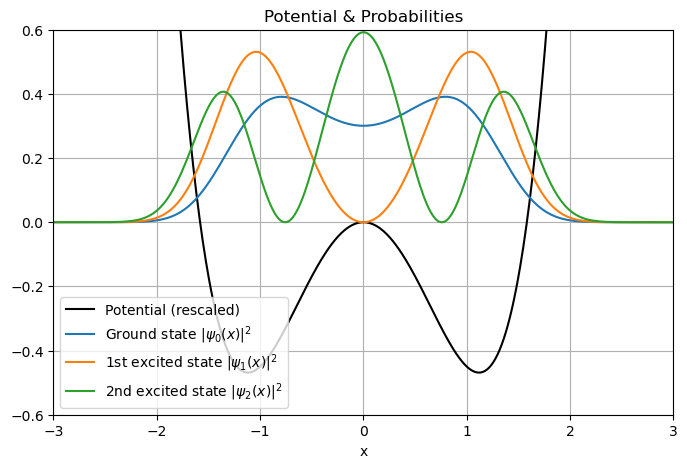

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

print("Ground state energy: ", E[0])
print("1st excited state energy: ", E[1])
print("2nd excited state energy: ", E[2])

# Plot a few things
plt.figure(figsize=(8,5))
scale = 0.3
plt.plot(x, scale*V, color="Black", label="Potential (rescaled)") # Plot the potential, riscalato per visualizzarlo meglio (Sarebbe troppo profondo)
plt.plot(x, psi[0]**2, label=r"Ground state $|\psi_0(x)|^2$")
plt.plot(x, psi[1]**2, label=r"1st excited state $|\psi_1(x)|^2$")
plt.plot(x, psi[2]**2, label=r"2nd excited state $|\psi_2(x)|^2$")

plt.title("Potential & Probabilities")
plt.xlabel("x")
plt.grid(True)
plt.legend()
plt.xlim((-3,3))
plt.ylim((-0.6,0.6))
plt.show()

## EXERCISE 08.1

### Assignment prompt

Write a Variational Monte Carlo code for a single quantum particle in 1D which exploits the Metropolis algorithm to sample the square modulus of our trial wave function $|\Psi_T^{\sigma,\mu}(x)|^2$ using an uniform transition probability $T(x_{new}|x_{old})$. By using data blocking, the code should be able to compute the expectation value for the Hamiltonian

$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} = 
\int dx \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2} \frac{{\hat H} \Psi_T(x)}{\Psi_T(x)}
$$

which can be used to find the parameters that minimize this quantity. Use $\hbar = 1$ and $m=1$.
Note that to measure $\langle {\hat H} \rangle_T$ you need the analytical calculation of:
    
$$
\frac{{-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}} \Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)}
$$

### Method

The code samples $|\Psi_T^{\sigma,\mu}(x)|^2$ with a uniform Metropolis move

$$
x' = x + \delta,
$$

where the displacement $\delta$ is uniformly extracted in the interval

$$
\delta \in [-1.2,1.2].
$$

For each Metropolis step, whether the proposed move is accepted or rejected, the current position is used to evaluate the local energy $E_L(x)$. Before starting the block averages, the code performs 1000 equilibration Metropolis steps. These steps are used only to reduce the dependence on the arbitrary initial position of the Markov chain, and they are not included in the energy averages.

The acceptance rate of the Metropolis walk is monitored and printed to terminal when the C++ code is executed (0.5011). It is not part of the energy estimator itself, but it is a useful diagnostic to check that the proposal step is reasonable and that the Markov chain samples the target distribution efficiently.

The run shown here uses the non-optimized test parameters

$$
\mu=1.0, \qquad \sigma=0.5.
$$

For this reason, the energy is not expected to be close to the optimal variational estimate. The purpose of Exercise 08.1 is to build and test the VMC estimator; the actual optimization of $\mu$ and $\sigma$ is performed in Exercise 08.2.

### C++ implementation

The local energy is computed as the sum of kinetic and potential contributions. Since $\hbar=m=1$, the Hamiltonian is

$$
\hat H=
-\frac{1}{2}\frac{d^2}{dx^2}+V(x),
$$

so the kinetic contribution to the local energy is

$$
-\frac{1}{2}\frac{\Psi_T''(x)}{\Psi_T(x)}.
$$

For the trial wave function

$$
\Psi_T^{\sigma,\mu}(x)=
e^{-\frac{(x-\mu)^2}{2\sigma^2}}
+
e^{-\frac{(x+\mu)^2}{2\sigma^2}},
$$

the second derivative is obtained by differentiating the two Gaussian terms:

$$
\Psi_T''(x)=
\left[
\frac{(x-\mu)^2}{\sigma^4}
-
\frac{1}{\sigma^2}
\right]
e^{-\frac{(x-\mu)^2}{2\sigma^2}}
+
\left[
\frac{(x+\mu)^2}{\sigma^4}
-
\frac{1}{\sigma^2}
\right]
e^{-\frac{(x+\mu)^2}{2\sigma^2}}.
$$

Therefore, the local energy used in the simulation is

$$
E_L(x)
=
\frac{\hat H\Psi_T(x)}{\Psi_T(x)}
=
\frac{\left[-\frac{1}{2}\frac{d^2}{dx^2}+V(x)\right]\Psi_T(x)}
{\Psi_T(x)}
=
-\frac{1}{2}\frac{\Psi_T''(x)}{\Psi_T(x)}
+
V(x).
$$

with

$$
V(x)=x^4-\frac{5}{2}x^2.
$$



```cpp
double potential(double x) {
    return pow(x, 4) - 2.5 * x * x;
}

double Energy(double x, double mu, double sigma) {
    double s2 = sigma * sigma;
    double s4 = s2 * s2;

    double g1 = exp(-pow(x - mu, 2) / (2.0 * s2));
    double g2 = exp(-pow(x + mu, 2) / (2.0 * s2));

    double psi_x = g1 + g2;

    double psi_second_derivative =
        g1 * (pow(x - mu, 2) / s4 - 1.0 / s2)
        + g2 * (pow(x + mu, 2) / s4 - 1.0 / s2);

    double kinetic = -0.5 * psi_second_derivative / psi_x;

    return kinetic + potential(x);
}
```

The sampled probability is proportional to $|\Psi_T(x)|^2$:

```cpp
double probability_distribution_squared_modulus(double x, double mu, double sigma) {
    double modulus_2 = pow(
        exp(-pow(x-mu,2)/(2*pow(sigma,2))) +
        exp(-pow(x+mu,2)/(2*pow(sigma,2))),
        2
    );
    return modulus_2;
}
```

The Metropolis acceptance step uses the ratio of the two probabilities. The proposal is symmetric, so the transition probability cancels:

```cpp
bool Acceptance(Random &rnd, double x, double x_new, int &accepted_per_block) {
    double A = min(
        1.0,
        probability_distribution_squared_modulus(x_new, mu, sigma)
        / probability_distribution_squared_modulus(x, mu, sigma)
    );

    if (rnd.Rannyu() < A) {
        accepted_per_block++;
        return true;
    } else {
        return false;
    }
}
```

These functions are then used inside the standard Metropolis scheme already introduced in the previous exercises. Starting from the current position $x$, the code proposes a new point $x'=x+\delta$, computes the acceptance probability from the ratio of $|\Psi_T|^2$, and either accepts the new point or keeps the old one. After each step, the current position is used to evaluate the local energy $E_L(x)$, which is accumulated block by block to obtain the final VMC estimate and its statistical uncertainty.

### Results

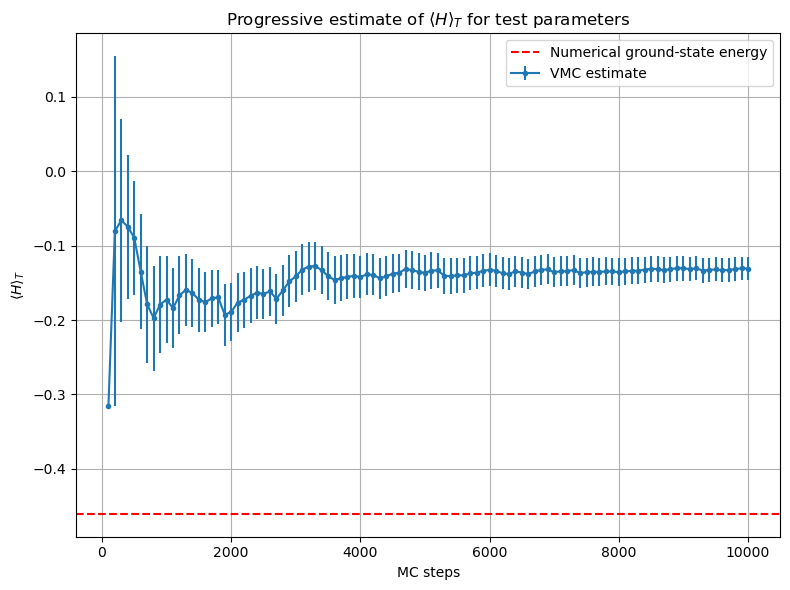

Final estimate with test parameters: -0.130714 +/- 0.015522


In [22]:
data_81 = pd.read_csv("Results/Esercizio_08.1_results.txt", sep=";")

N_throws_81 = 10000
N_blocks_81 = len(data_81) #100 blocchi 
throws_per_block_81 = N_throws_81 / N_blocks_81
mc_steps_81 = np.arange(1, N_blocks_81 + 1) * throws_per_block_81

plt.figure(figsize=(8, 6))
plt.errorbar(
    mc_steps_81,
    data_81["Progressive_ground_state_Energy"],
    yerr=data_81["Progressive_ground_state_Energy_error"],
    fmt="-o",
    ms=3,
    label="VMC estimate"
)
plt.axhline(E[0], color="r", linestyle="--", label="Numerical ground-state energy")
plt.title(r"Progressive estimate of $\langle H \rangle_T$ for test parameters")
plt.xlabel("MC steps")
plt.ylabel(r"$\langle H \rangle_T$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

final_81 = data_81.iloc[-1]
print(
    "Final estimate with test parameters: "
    f"{final_81['Progressive_ground_state_Energy']:.6f} +/- "
    f"{final_81['Progressive_ground_state_Energy_error']:.6f}"
)


#100 blocchi da 100 step

### Comment

The final estimate obtained with the test parameters is much higher than the numerical ground-state energy. This is consistent with the variational principle: a non-optimal trial wave function gives an upper bound that can be far from the true ground-state energy.

The important point of this first part is that the Metropolis sampling and the data-blocking estimator are working. Once this estimator is available, the same code can be used inside an optimization procedure to search for better values of $\mu$ and $\sigma$.

## EXERCISE 08.2

### Assignment prompt

To find the parameters $\sigma$ and $\mu$ which minimize $\langle {\hat H} \rangle_T$, extend your Variational Monte Carlo code to face the variational optimization problem via a Simulated Annealing (SA) algorithm.

Choose an appropriate starting temperature for your SA algorithm and an appropriate temperature-update-law to make the optimization work.

Compute $\langle {\hat H} \rangle_T$ with enough statistics in order to be able to measure the lowering of $\langle {\hat H} \rangle_T$ once the variational parameters are moved.

- Show a picture of $\langle {\hat H} \rangle_T$ (with statistical uncertainties) as a function of the SA steps of the algorithm
- you could also show a picture of the trajectory of the SA algorithm in the variational parameter space as a function of the SA steps
- show a picture of the estimation of $\langle {\hat H} \rangle_T$ and its statistical uncertainty as a function of the number of blocks/MC steps for the set of parameters which minimize $\langle {\hat H} \rangle_T$
- show also a picture **of the sampled** $|\Psi_T(x)|^2$ by filling a histogram with the sampled configurations, moreover compare it with the analytic curve of $|\Psi_T(x)|^2$ and with the numerical solution obtained by transforming the Schrodinger equation into a matrix equation (see below the supplementary material).

### Method: Simulated Annealing

In the implementation of Exercise 08.2, the Simulated Annealing algorithm does not compute the variational energy directly inside the main optimization code. Instead, for each proposed pair of parameters $(\mu,\sigma)$, it launches the external program `energia.exe`.

This program performs the same VMC procedure introduced in Exercise 08.1: it samples positions $x$ according to $|\Psi_T^{\sigma,\mu}(x)|^2$, evaluates the local energy $E_L(x)$, and averages it with the blocking method.

At the end of each run, `energia.exe` prints to terminal two numbers:

$$
E(\mu,\sigma), \qquad \sigma_E(\mu,\sigma).
$$

The first number is the final progressive block average and the second number is the corresponding statistical uncertainty obtained with data blocking. Therefore, the energy used by the Simulated Annealing algorithm is not the value of a single block, but the final block-averaged VMC estimate for the proposed parameters.

During the Simulated Annealing optimization, each call to `energia.exe` uses 100 blocks and 100 Metropolis steps per block, for a total of 10000 measured VMC steps after the initial equilibration of 1000 steps. The energy printed by `energia.exe` is then read by the Simulated Annealing code and used as the quantity to minimize in the Metropolis acceptance rule in parameter space.

The run uses 1000 temperature values and 100 attempted parameter moves for each temperature, for a total of 100000 Simulated Annealing moves. During the run, the code records both the trajectory of the parameters and the estimated energy values.

During the annealing run, many different pairs $(\mu,\sigma)$ are tested. For each pair, `energia.exe` gives a Monte Carlo estimate of the variational energy. Since this estimate is obtained with a finite number of sampled points, it has a statistical fluctuation.

For this reason, the pair with the lowest energy found during the annealing is used to identify the optimal region of the parameter space. However, the corresponding SA energy value is not taken as the final result, because it may be slightly affected by the statistical noise of that particular VMC run.

After the optimization, the best parameters found by the SA are kept fixed and a **longer** VMC simulation is performed. This final run gives a more reliable estimate of the variational energy and of its statistical uncertainty.

### C++ implementation

The Simulated Annealing code is based on repeated evaluations of the variational energy. For a fixed pair of parameters $(\mu,\sigma)$, this energy is not computed directly inside the SA program. Instead, the code launches the executable `energia.exe`, passing the current values of $\mu$ and $\sigma$ as command-line arguments:

```cpp
cmd << "./energia.exe "
    << setprecision(17) << mu << " "
    << setprecision(17) << sigma;

FILE* pipe = popen(cmd.str().c_str(), "r");
```

The program `energia.exe` then performs a VMC simulation for those parameters and prints the final progressive block average of the variational energy, together with its statistical uncertainty. These two numbers are read by the Simulated Annealing code and used to decide whether the current pair of parameters should be accepted.

The annealing temperature is decreased during the run according to

```cpp
double T_current = 1.0 / double(i + 1);
```

where `i` is the temperature index. Therefore, the temperature is high at the beginning and becomes progressively smaller as the optimization proceeds.

At each Simulated Annealing step, the code proposes a random move in the parameter space:

```cpp
double mu_new = mu + rnd.Rannyu(-0.04, 0.04);
double sigma_new = sigma + rnd.Rannyu(-0.03, 0.03);
```

The proposed displacements are uniform and have fixed width during the whole run. If the proposed value of $\sigma$ becomes too small, the move is rejected immediately, because $\sigma$ must remain positive:

```cpp
if (sigma_new <= sigma_min) {
    return H_current;
}
```

Once the new parameters are proposed, the code evaluates the new variational energy $H_{\text{new}}$ by calling again `energia.exe`. The proposed parameters are then accepted or rejected with a Metropolis rule based on the difference between the new and old energies:

```cpp
double probability_distribution(double H_current, double H_new, double T) {
    double pdf = exp(-(H_new - H_current) / T);
    return pdf;
}

bool Acceptance(Random &rnd, double H_current, double H_new,
                int &accepted_per_temperature, double T) {
    double A = min(1.0, probability_distribution(H_current, H_new, T));

    if (rnd.Rannyu() < A) {
        accepted_per_temperature++;
        return true;
    } else {
        return false;
    }
}
```


During the annealing run, the code keeps track of the best parameters found so far. Whenever the current energy is lower than the previous best value, the corresponding values of $\mu$ and $\sigma$ are stored:

```cpp
if (H_current < best_H) {
    best_H = H_current;
    best_H_error = H_current_error;
    best_mu = mu;
    best_sigma = sigma;
}
```

The trajectory of the optimization in the parameter space is also saved:

```cpp
trajectory << SA_step << ";"
           << mu << ";"
           << sigma << endl;
```

This makes it possible to plot how the algorithm moves in the $(\mu,\sigma)$ plane during the annealing process.

After the Simulated Annealing optimization, the best parameters are kept fixed and a final VMC simulation is performed with larger statistics. This final run is launched manually with `energia.exe`, adding the option `save_blocks` after the optimized values of $\mu$ and $\sigma$:

```bash
./energia.exe 0.833341 0.610485 save_blocks
```

In `energia.cpp`, this option activates the production run:

```cpp
if (save_blocks) {
    N_throws = 1000000;
} else {
    N_throws = 10000;
}
```

Therefore, during the SA each energy evaluation uses only `10000` measured Metropolis steps, because the energy must be evaluated many times. In the final run, instead, the optimized parameters are already fixed, so the code uses `1000000` measured Metropolis steps to obtain a more precise estimate.

The same `save_blocks` option also makes the program save the sampled configurations:

```cpp
if (save_samples) {
    samples.open("../sampled_configurations.dat");
    samples << "x" << endl;
}
```

The final run therefore produces both the progressive energy file,

```text
Esercizio_08.2_final_energy_blocks.txt
```

and the sampled configurations file,

```text
sampled_configurations.dat
```

The sampled positions are then used to build the histogram of the probability density and to compare the VMC sampled distribution with the analytical trial density and with the numerical solution of the Schrödinger equation.

### Simulated Annealing energy

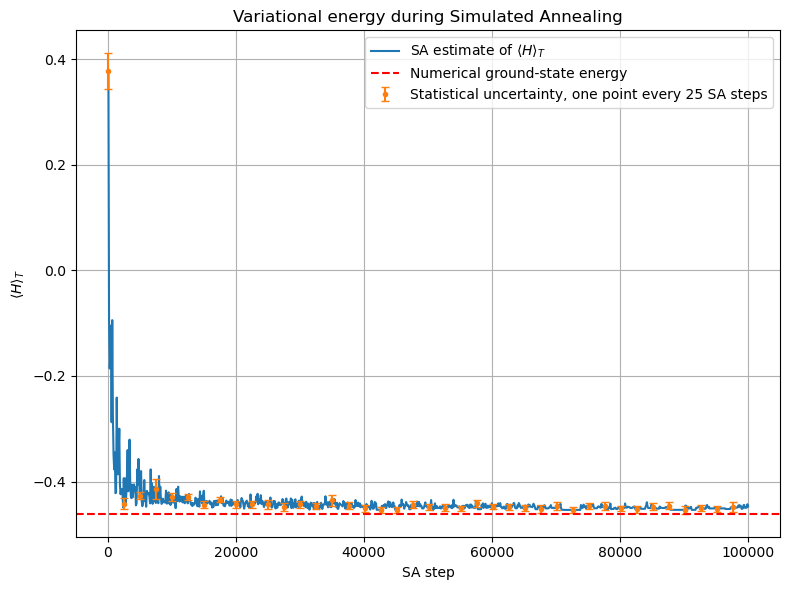

Best SA parameters: mu = 0.833341, sigma = 0.610485
Best SA energy estimate: -0.454302 +/- 0.006063


In [23]:
sa_energy = pd.read_csv("Results/Esercizio_08.2_SA_energy_steps.txt", sep=";")
best = pd.read_csv("Results/best_parameters.dat", sep=";")

best_mu = best["mu"].iloc[0]
best_sigma = best["sigma"].iloc[0]
best_sa_energy = best["Energy"].iloc[0]
best_sa_error = best["Energy_error"].iloc[0]

error_stride = 25

plt.figure(figsize=(8, 6))
plt.plot(
    sa_energy["SA_step"],
    sa_energy["Energy"],
    label=r"SA estimate of $\langle H \rangle_T$"
)
plt.errorbar(
    sa_energy["SA_step"].iloc[::error_stride],
    sa_energy["Energy"].iloc[::error_stride],
    yerr=sa_energy["Energy_error"].iloc[::error_stride],
    fmt="o",
    ms=3,
    capsize=3,
    label=f"Statistical uncertainty, one point every {error_stride} SA steps"
)
plt.axhline(E[0], color="r", linestyle="--", label="Numerical ground-state energy")
plt.title(r"Variational energy during Simulated Annealing")
plt.xlabel("SA step")
plt.ylabel(r"$\langle H \rangle_T$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best SA parameters: mu = {best_mu:.6f}, sigma = {best_sigma:.6f}")
print(f"Best SA energy estimate: {best_sa_energy:.6f} +/- {best_sa_error:.6f}")

### Comment

The annealing run clearly lowers the variational energy from the initial high values toward the region close to the ground-state energy. The statistical error bars are shown only every few SA steps to keep the plot readable.

The best energy found during SA is

$$
E_{SA,best} = -0.454302 \pm 0.006063,
$$

at approximately

$$
\mu = 0.833341, \qquad \sigma = 0.610485.
$$

This energy estimate is compatible, within its statistical uncertainty, with values close to the exact reference. However, it should not be interpreted as the final precise energy. During SA, each energy evaluation is relatively noisy because it is used mainly to guide the optimization. A longer fixed-parameter VMC run is needed for the final estimate.

### Trajectory in the variational parameter space

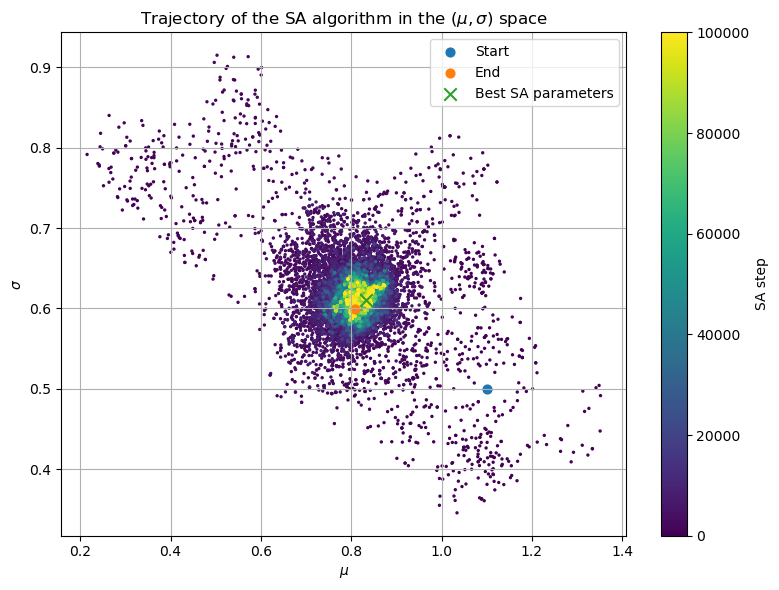

In [24]:
trajectory = pd.read_csv("Results/trajectory_mu_sigma.dat", sep=";")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    trajectory["mu"],
    trajectory["sigma"],
    c=trajectory["SA_step"],
    marker=".",
    s=8
)
plt.scatter(
    trajectory["mu"].iloc[0],
    trajectory["sigma"].iloc[0],
    marker="o",
    s=40,
    label="Start"
)
plt.scatter(
    trajectory["mu"].iloc[-1],
    trajectory["sigma"].iloc[-1],
    marker="o",
    s=40,
    label="End"
)
plt.scatter(
    best_mu,
    best_sigma,
    marker="x",
    s=80,
    label="Best SA parameters"
)
plt.title(r"Trajectory of the SA algorithm in the $(\mu,\sigma)$ space")
plt.xlabel(r"$\mu$")
plt.ylabel(r"$\sigma$")
plt.grid(True)
plt.colorbar(scatter, label="SA step")
plt.legend()
plt.tight_layout()
plt.show()

### Comment

The trajectory starts from the initial point $(\mu,\sigma)=(1.1,0.5)$ and then explores the parameter space. As the temperature decreases, accepted moves become more selective and the trajectory spends more time near a narrow region of parameters.

The final point of the trajectory is not necessarily identical to the best point found during the whole annealing process: the algorithm stores the best energy encountered during the search, while the final point is simply the last accepted state.

### Final VMC estimate at optimized parameters

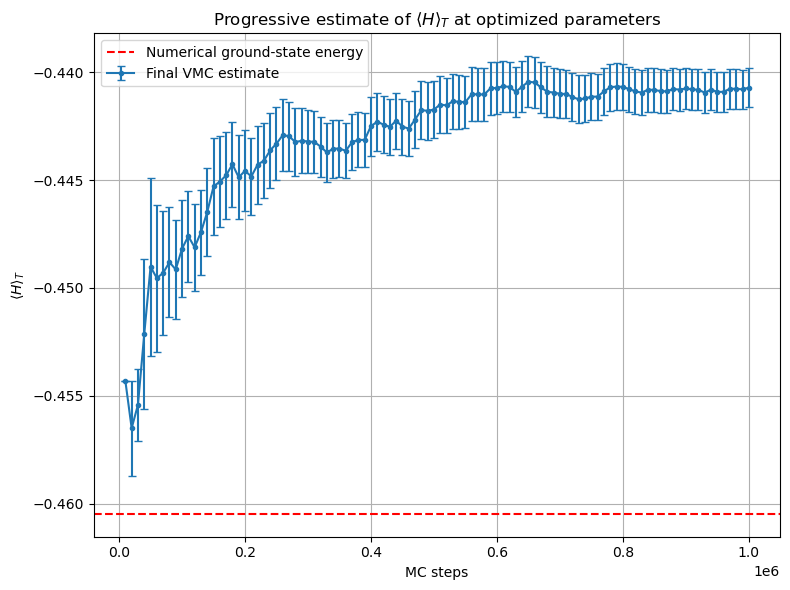

Final fixed-parameter VMC estimate: -0.440718 +/- 0.000911
Numerical reference energy: -0.460466


In [25]:
final_energy = pd.read_csv("Results/Esercizio_08.2_final_energy_blocks.txt", sep=";")

plt.figure(figsize=(8, 6))
plt.errorbar(
    final_energy["MC_steps"],
    final_energy["Progressive_Energy"],
    yerr=final_energy["Progressive_Energy_error"],
    fmt="-o",
    ms=3,
    capsize=3,
    label="Final VMC estimate"
)
plt.axhline(E[0], color="r", linestyle="--", label="Numerical ground-state energy")
plt.title(r"Progressive estimate of $\langle H \rangle_T$ at optimized parameters")
plt.xlabel("MC steps")
plt.ylabel(r"$\langle H \rangle_T$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

final_row = final_energy.iloc[-1]
print(
    "Final fixed-parameter VMC estimate: "
    f"{final_row['Progressive_Energy']:.6f} +/- "
    f"{final_row['Progressive_Energy_error']:.6f}"
)
print(f"Numerical reference energy: {E[0]:.6f}")

### Comment

The final long VMC run at fixed optimized parameters gives

$$
\langle H \rangle_T = -0.440718 \pm 0.000911.
$$

This is the value used as the final VMC estimate of the ground-state energy. It is higher than the numerical reference value

$$
E_0 \simeq -0.460466,
$$

as required by the variational principle.

During the Simulated Annealing search, the lowest energy encountered was

$$
E_{\mathrm{SA,best}} = -0.454302 \pm 0.006063.
$$

This value is lower and therefore apparently closer to the exact numerical result. However, it was obtained during the optimization from a shorter VMC evaluation and has a much larger statistical uncertainty. It can therefore be affected by a favourable statistical fluctuation.

For this reason, the SA value is used only to locate a good region in the parameter space $(\mu,\sigma)$, not as the final energy estimate. The reliable result is the final fixed-parameter VMC run, because it is performed after the optimization with larger statistics and gives a more stable estimate of the variational energy.

### Sampled probability density and comparison with the exact solution

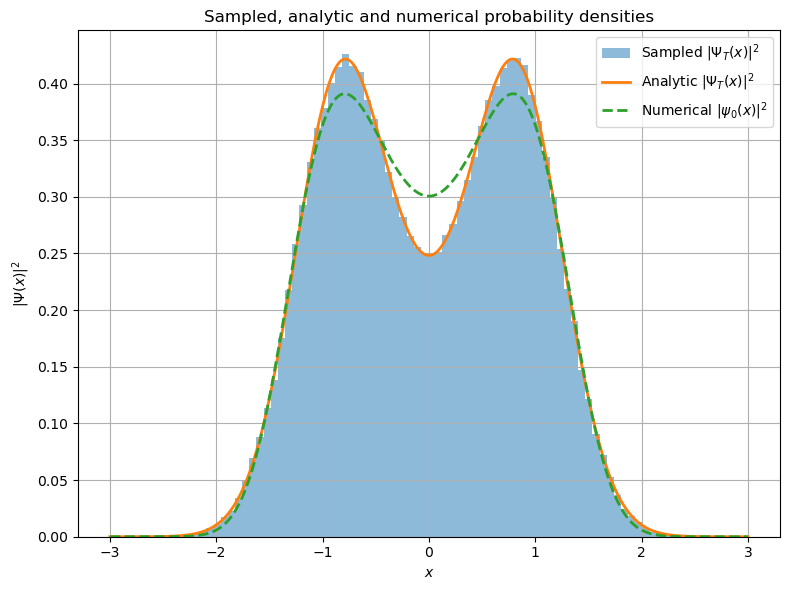

In [26]:
def psi_trial(x, mu, sigma):
    return (
        np.exp(-((x - mu)**2) / (2 * sigma**2)) +
        np.exp(-((x + mu)**2) / (2 * sigma**2))
    )

def normalize_density(y, x):
    return y / np.trapz(y, x)

def trial_density(x, mu, sigma):
    psi_trial_values = psi_trial(x, mu, sigma)
    return normalize_density(psi_trial_values**2, x)


samples = pd.read_csv("Results/sampled_configurations.dat")
x_samples = samples["x"].values

x_grid = np.linspace(-3.0, 3.0, 1000)
psi_T_squared = trial_density(x_grid, best_mu, best_sigma)

mask_exact = (x >= -3.0) & (x <= 3.0)

plt.figure(figsize=(8, 6))
plt.hist(
    x_samples,
    bins=80,
    density=True,
    alpha=0.5,
    label=r"Sampled $|\Psi_T(x)|^2$"
)
plt.plot(
    x_grid,
    psi_T_squared,
    linewidth=2,
    label=r"Analytic $|\Psi_T(x)|^2$"
)
plt.plot(
    x[mask_exact],
    psi[0][mask_exact]**2,
    linestyle="--",
    linewidth=2,
    label=r"Numerical $|\psi_0(x)|^2$"
)

plt.title(r"Sampled, analytic and numerical probability densities")
plt.xlabel(r"$x$")
plt.ylabel(r"$|\Psi(x)|^2$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Comment

In this plot, the histogram represents the sampled probability density.

The continuous curve labelled as analytic $|\Psi_T(x)|^2$ is the trial probability density computed directly from the optimized trial wave function, using the best values of $\mu$ and $\sigma$ found by the Simulated Annealing.

The dashed curve labelled as numerical $|\psi_0(x)|^2$ is the reference ground-state probability density obtained by diagonalizing the discretized Hamiltonian matrix.

The histogram of the sampled configurations follows the analytic curve of $|\Psi_T(x)|^2$ computed with the optimized parameters. This confirms that the Metropolis sampling is working correctly: the Markov chain is sampling the intended probability density.

The optimized trial density has the same main double-well shape as the numerical ground-state density. The differences are expected because the trial wave function is only an approximation.

This agrees with the energy comparison: the VMC result is reasonable, but it remains above the exact numerical energy, as required by the variational principle.